# Accumulation time by off time

In [1]:
import os
import sys

path = os.path.abspath("")
splitted = path.split(os.sep)
user_independent = os.path.join(
    splitted[0] + os.sep, splitted[1], splitted[2], splitted[3]
)
src_path = os.path.join(user_independent, "GitHub", "Photoswitching")
sys.path.append(src_path)

import src.blinking as bl
import src.distributions as dist
import src.emissions as em
import src.fcs as fcs_p
import src.figure as fi
import src.fluorophores as fl
import src.formulas as fo
import src.miscellaneous as mi
import src.network as net
import src.simulation as si
import src.prediction as pr
import src.analysis as an
import src.transitions as tr

import numpy as np
import pandas as pd

%load_ext autoreload
%autoreload 2

import warnings


def custom_warning_format(msg, category, filename, lineno, line=None):
    if line is None:
        import linecache

        line = linecache.getline(filename, lineno)
    return f"WARNING for line: {line} {msg} \n"


warnings.formatwarning = custom_warning_format

In [2]:
number_fluorophores = 1
distance = None
energy_transfers = False

irradiance = 2.5
wavelength = 640

photon_collection_rate = 0.01
emccd_gain = 100
bandpass_range = [600, 800]
frame_integration_time = '1ms'
quantum_eff_detec = 0.9

fluorophores = fl.construct_fluorophores('cy5', 1, number_fluorophores, 'square')
fluorophore_system = fl.FluorophoreSystem(fluorophores=fluorophores)
transitions = fluorophore_system.load_transitions(
    irradiance=irradiance, 
    wavelength=wavelength,
    bleaching=True,
    energy_transfer=False,
    dstorm=True,
    reducing_agent='mea',
    concentration=140,
    ph=8,
)
transition_set = tr.TransitionSet(transitions=transitions, fluorophore_system=fluorophore_system)
transition_set = transition_set.adjust_rates({12:5e2})

In [9]:
transition_set_1_f_off_high = transition_set.adjust_rates({11:2e-1})
transition_set_1_f_off_high.finalize()

simulation_1_f_off_high = si.Simulation(transition_set_1_f_off_high)
bleaching_transitions = transition_set_1_f_off_high.combined_state_transitions_df[transition_set_1_f_off_high.combined_state_transitions_df['abbreviation'] == 'BLE1']
series_1_f_off_high = pd.Series(np.zeros(300001), np.linspace(0, 300, 300001))
time_collection_1_f_off_high = []
rng = np.random.default_rng(1)
for _ in range(100):
    simulation_1_f_off_high.run(start_at=None, size=1e6, end_time=300, seed=rng, use_memmap=None)
    times = simulation_1_f_off_high.time_series[1:-1][np.in1d(simulation_1_f_off_high.transition_series, bleaching_transitions.index)]
    time_collection_1_f_off_high.append(times)
    emissions = em.Emissions(frame_time=frame_integration_time, seed=1, bandpass=bandpass_range)
    emissions.extract(simulation=simulation_1_f_off_high)
    series_1_f_off_high = series_1_f_off_high + emissions.event_time_series.values

rel_emission_1_f_off_high = series_1_f_off_high.cumsum() / series_1_f_off_high.sum()

In [10]:
transition_set_1_f_off_mid = transition_set.adjust_rates({11:2e-2})
transition_set_1_f_off_mid.finalize()

simulation_1_f_off_mid = si.Simulation(transition_set_1_f_off_mid)
bleaching_transitions = transition_set_1_f_off_mid.combined_state_transitions_df[transition_set_1_f_off_mid.combined_state_transitions_df['abbreviation'] == 'BLE1']
series_1_f_off_mid = pd.Series(np.zeros(300001), np.linspace(0, 300, 300001))
time_collection_1_f_off_mid = []
rng = np.random.default_rng(1)
for _ in range(100):
    simulation_1_f_off_mid.run(start_at=None, size=1e6, end_time=300, seed=rng, use_memmap=None)
    times = simulation_1_f_off_mid.time_series[1:-1][np.in1d(simulation_1_f_off_mid.transition_series, bleaching_transitions.index)]
    time_collection_1_f_off_mid.append(times)
    emissions = em.Emissions(frame_time=frame_integration_time, seed=1, bandpass=bandpass_range)
    emissions.extract(simulation=simulation_1_f_off_mid)
    series_1_f_off_mid = series_1_f_off_mid + emissions.event_time_series.values

rel_emission_1_f_off_mid = series_1_f_off_mid.cumsum() / series_1_f_off_mid.sum()

In [11]:
transition_set_1_f_off_low = transition_set.adjust_rates({11:2e-3})
transition_set_1_f_off_low.finalize()

simulation_1_f_off_low = si.Simulation(transition_set_1_f_off_low)
bleaching_transitions = transition_set_1_f_off_low.combined_state_transitions_df[transition_set_1_f_off_low.combined_state_transitions_df['abbreviation'] == 'BLE1']
series_1_f_off_low = pd.Series(np.zeros(300001), np.linspace(0, 300, 300001))
time_collection_1_f_off_low = []
rng = np.random.default_rng(1)
for _ in range(100):
    simulation_1_f_off_low.run(start_at=None, size=1e6, end_time=300, seed=rng, use_memmap=None)
    times = simulation_1_f_off_low.time_series[1:-1][np.in1d(simulation_1_f_off_low.transition_series, bleaching_transitions.index)]
    time_collection_1_f_off_low.append(times)
    emissions = em.Emissions(frame_time=frame_integration_time, seed=1, bandpass=bandpass_range)
    emissions.extract(simulation=simulation_1_f_off_low)
    series_1_f_off_low = series_1_f_off_low + emissions.event_time_series.values

rel_emission_1_f_off_low = series_1_f_off_low.cumsum() / series_1_f_off_low.sum()

array([[<Axes: xlabel='time [s]', ylabel='% emission'>]], dtype=object)

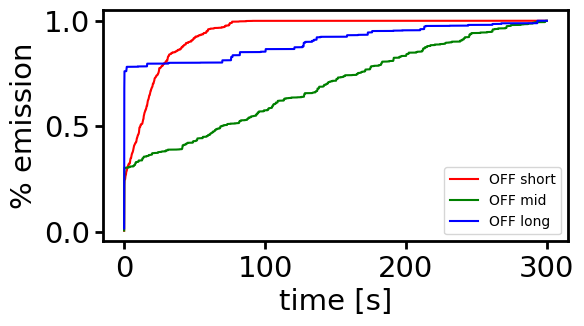

In [12]:
ax = fi.universal_figure(data=[series_1_f_off_high.index, rel_emission_1_f_off_high], label='OFF short', color='red')
fi.universal_figure(data=[series_1_f_off_mid.index, rel_emission_1_f_off_mid], label='OFF mid', axes=ax, color='green')
fi.universal_figure(data=[series_1_f_off_low.index, rel_emission_1_f_off_low], label='OFF long', axes=ax, color='blue', legend=True, xlabel='time [s]', ylabel='% emission')